# デリーの気候データ（学習データ）の探索的データ分析（EDA）

- **作成者**: ImoZukushi
- **作成日**: 2026-09-27
- **目的**: `data/raw/DailyDelhiClimateTrain.csv` の品質・分布・時系列的な性質・季節性を確認し、
  予測モデルを作る前に注意すべき点（記録の誤り、季節性、長期的な変化）を把握する。
- **元スクリプト**: `scripts/eda_delhi_climate.py`（同じ処理をCLIで実行できる）

## このノートブックでやること

`src/` 配下のモジュールを使い、汎用のデータ品質確認・時系列診断に加えて、このデータ固有の確認を行います。

1. 読み込み（`util.csv_io.read_csv_auto`: エンコーディング自動判定・日付列の自動パース）
2. データ品質確認（`eda.csv_quality.run_quality_checks`）
   - データフレーム全体の概要（行数・列数・重複・欠損）とカラム単位の要約統計
   - ヒストグラム・相関ヒートマップ・記録パターン・散布図行列
3. 時系列診断（`eda.time_series_eda.run_time_series_checks`）
   - 変数ごとに、原系列・対数・差分・対数差分・季節差分・季節対数差分の6系列について
     「生値と移動平均」「ACF」「PACF」の図を作成
   - 日次データのため、移動平均は30日、季節差分の周期は365日（年周期）とする
4. このデータ固有の確認
   - 日付の連続性（欠けている日・重複している日の有無）
   - 物理的にありうる範囲の外にある値（測定・記録の誤りの候補）
   - 月別の分布（箱ひげ図）で季節性を確認
   - 年別の平均で長期的な推移を確認

### 物理的にありうる範囲（このノートブックの仮定）
デリーの気候として明らかにおかしい値を検出するための目安です。

| 変数 | 意味 | 範囲 |
|---|---|---|
| `meantemp` | 日平均気温 (℃) | -10〜50 |
| `humidity` | 湿度 (%) | 0〜100 |
| `wind_speed` | 風速 (km/h) | 0〜100 |
| `meanpressure` | 平均気圧 (hPa) | 950〜1050 |

## 1. ライブラリの読み込み

リポジトリの `src/` をimportできるよう、`pyproject.toml` のあるディレクトリ（リポジトリルート）を探して
`sys.path` に追加します。ノートブックをどのディレクトリから開いても動くようにするためです。

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import polars as pl
import seaborn as sns
from IPython.display import Image, display

# pyproject.toml を目印にリポジトリルートを探し、src/ をimportパスに追加する
REPO_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").is_file())
if str(REPO_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / "src"))

# src/ 配下のモジュール（上でパスを追加した後にimportする必要がある）
from eda.csv_quality import run_quality_checks  # noqa: E402
from eda.time_series_eda import run_time_series_checks  # noqa: E402
from util.csv_io import read_csv_auto  # noqa: E402
from util.paths import data_dir, ensure_parent_dir, outputs_dir  # noqa: E402
from util.plotting import add_caption, ensure_japanese_font  # noqa: E402

# polars の表示で列を省略しすぎないようにする
pl.Config.set_tbl_cols(20)

polars.config.Config

## 2. 実行パラメータと定数

次のセルは papermill のパラメータセル（`parameters` タグ付き）です。
`OUTPUT_ROOT` を `None` にすると `outputs/` に保存します。

In [2]:
OUTPUT_ROOT = None

In [3]:
# 出力のルート（papermill から文字列で渡された場合も Path に変換する）
ROOT = Path(OUTPUT_ROOT) if OUTPUT_ROOT is not None else outputs_dir()
FIGURES_DIR = ROOT / "figures"
TABLES_DIR = ROOT / "tables"

# 入力ファイル（data/raw は読み取り専用として扱い、書き込まない）
TRAIN_PATH = data_dir() / "raw" / "DailyDelhiClimateTrain.csv"
DATASET_NAME = "delhi_climate_train"  # 出力ファイル名の先頭に付ける識別名
TIME_COL = "date"

# 分析対象の数値変数と、図に使う日本語名・単位
VARIABLE_LABELS = {
    "meantemp": "日平均気温 (℃)",
    "humidity": "湿度 (%)",
    "wind_speed": "風速 (km/h)",
    "meanpressure": "平均気圧 (hPa)",
}

# 物理的にありうる範囲（下限, 上限）。範囲外は測定・記録の誤りの候補とみなす
PLAUSIBLE_RANGES = {
    "meantemp": (-10.0, 50.0),
    "humidity": (0.0, 100.0),
    "wind_speed": (0.0, 100.0),
    "meanpressure": (950.0, 1050.0),
}

# 時系列診断のパラメータ（日次データ向け）
MOVING_AVERAGE_WINDOW = 30  # 約1か月の移動平均で季節の推移を見る
SEASONAL_PERIOD = 365  # 年周期の季節差分
NLAGS = 60  # ACF/PACFで表示するラグ数（約2か月）

print(f"出力先: 図 {FIGURES_DIR} / 表 {TABLES_DIR}")

出力先: 図 C:\Users\imo_z\SIGNATE\analytics_cup_2026\outputs\figures / 表 C:\Users\imo_z\SIGNATE\analytics_cup_2026\outputs\tables


## 3. 読み込み

日付列は `Datetime` 型として読み込まれます。日付の昇順に並べてから分析します。

In [4]:
df = read_csv_auto(TRAIN_PATH).sort(TIME_COL)
print(f"読み込み: {TRAIN_PATH.name} {df.height}行 × {df.width}列")
print(df.schema)
df.head()

読み込み: DailyDelhiClimateTrain.csv 1462行 × 5列
Schema({'date': Datetime(time_unit='us', time_zone=None), 'meantemp': Float64, 'humidity': Float64, 'wind_speed': Float64, 'meanpressure': Float64})


date,meantemp,humidity,wind_speed,meanpressure
datetime[μs],f64,f64,f64,f64
2013-01-01 00:00:00,10.0,84.5,0.0,1015.666667
2013-01-02 00:00:00,7.4,92.0,2.98,1017.8
2013-01-03 00:00:00,7.166667,87.0,4.633333,1018.666667
2013-01-04 00:00:00,8.666667,71.333333,1.233333,1017.166667
2013-01-05 00:00:00,6.0,86.833333,3.7,1016.5


## 4. データ品質確認

`run_quality_checks` が、全体概要・カラム要約の表と、品質確認の図をまとめて作成・保存します。
（欠損が無い・カテゴリ列が無いデータでは、欠損の図・カテゴリの図は作成されません）

In [5]:
df_overview, col_overview = run_quality_checks(
    df,
    DATASET_NAME,
    source_path=str(TRAIN_PATH.relative_to(data_dir() / "raw")),
    figures_dir=FIGURES_DIR,
    tables_dir=TABLES_DIR,
)
df_overview

dataset,source_path,n_rows,n_columns,n_duplicated_rows,duplicated_row_rate,n_columns_with_missing,total_missing_cells,missing_cell_rate,estimated_memory_mb
str,str,i64,i64,i64,f64,i64,i64,f64,f64
"""delhi_climate_train""","""DailyDelhiClimateTrain.csv""",1462,5,0,0.0,0,0,0.0,0.055771


### 4.1 カラム単位の要約統計

`meanpressure` の最大値・歪度が他の変数に比べて極端に大きい点に注目します（記録の誤りの可能性。6章で確認）。

In [6]:
col_overview

dataset,column,dtype,is_numeric,n_rows,n_missing,missing_rate,n_unique,unique_rate,mode,mode_rate,mean,std,min,p25,median,p75,max,skewness
str,str,str,bool,i64,i64,f64,i64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""delhi_climate_train""","""date""","""Datetime(time_unit='us', time_…",false,1462,0,0.0,1462,1.0,"""2013-01-01 00:00:00""",0.000684,null,null,null,null,null,null,null,null
"""delhi_climate_train""","""meantemp""","""Float64""",true,1462,0,0.0,617,0.422025,"""31.0""",0.012312,25.495521,7.348103,6.0,18.857143,27.714286,31.3125,38.714286,-0.445894
"""delhi_climate_train""","""humidity""","""Float64""",true,1462,0,0.0,897,0.613543,"""65.5""",0.006156,60.771702,16.769652,13.428571,50.375,62.625,72.25,100.0,-0.343624
"""delhi_climate_train""","""wind_speed""","""Float64""",true,1462,0,0.0,771,0.52736,"""0.0""",0.017784,6.802209,4.561602,0.0,3.475,6.221667,9.25,42.22,1.435103
"""delhi_climate_train""","""meanpressure""","""Float64""",true,1462,0,0.0,626,0.428181,"""1017.0""",0.008892,1011.104548,180.231668,-3.041667,1001.571429,1008.563492,1014.947368,7679.333333,34.400546


### 4.2 分布・相関・記録パターン

- **ヒストグラム**: 各変数の分布の形（`meanpressure` は異常値に引っ張られて横軸が極端に広い）
- **相関ヒートマップ**: 変数間の直線的な関係（気温と湿度・気圧の関係など）
- **記録パターン**: 行の並び（時間順）に沿った値の変化。異常値がいつ発生したかの目視確認
- **散布図行列**: 変数の組み合わせごとの関係（対角はヒストグラム）

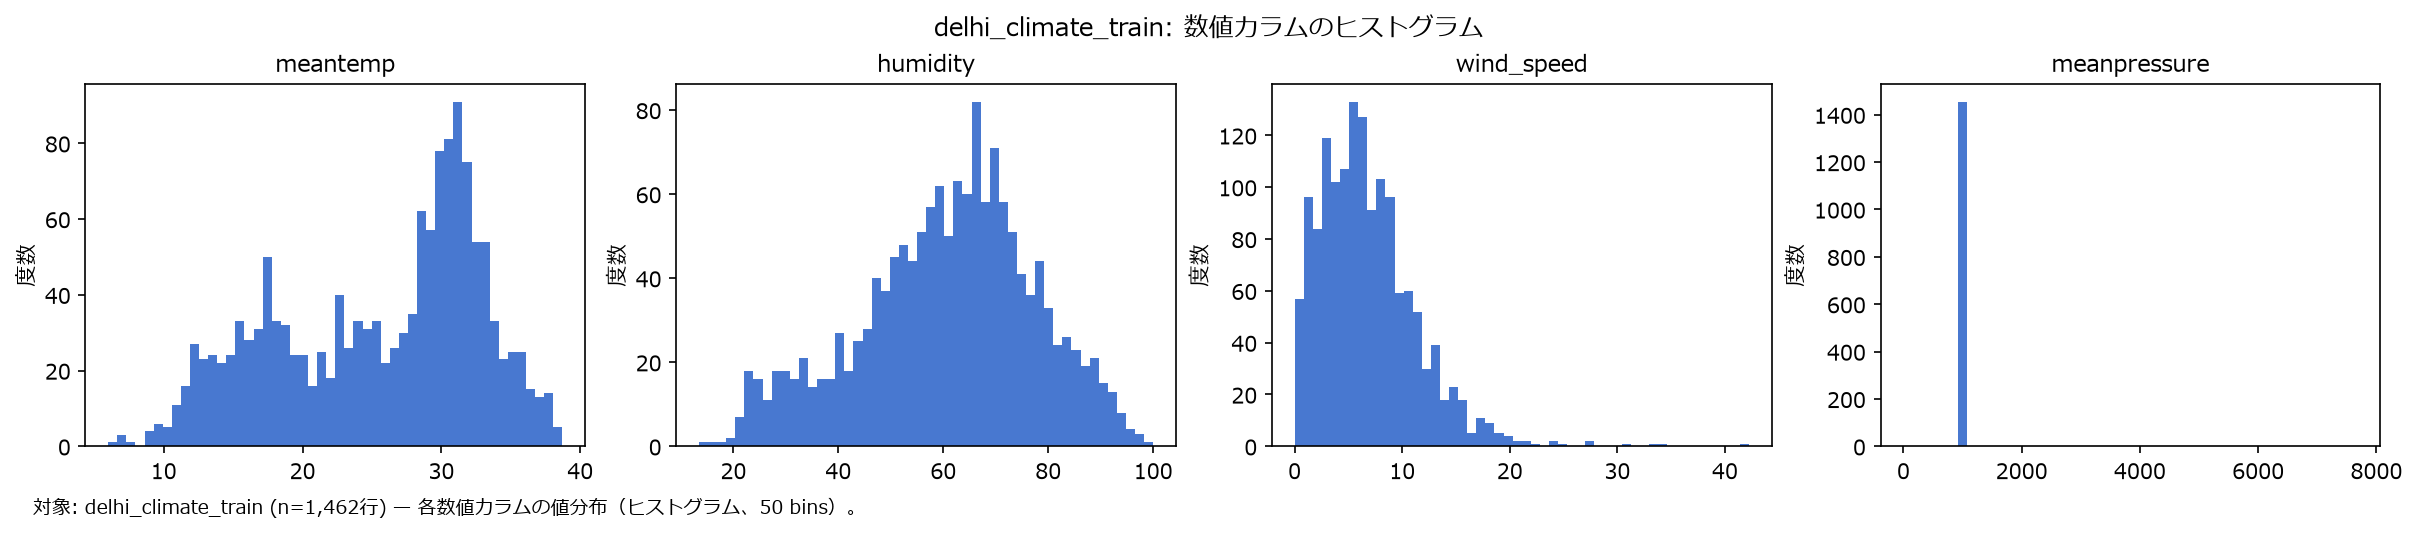

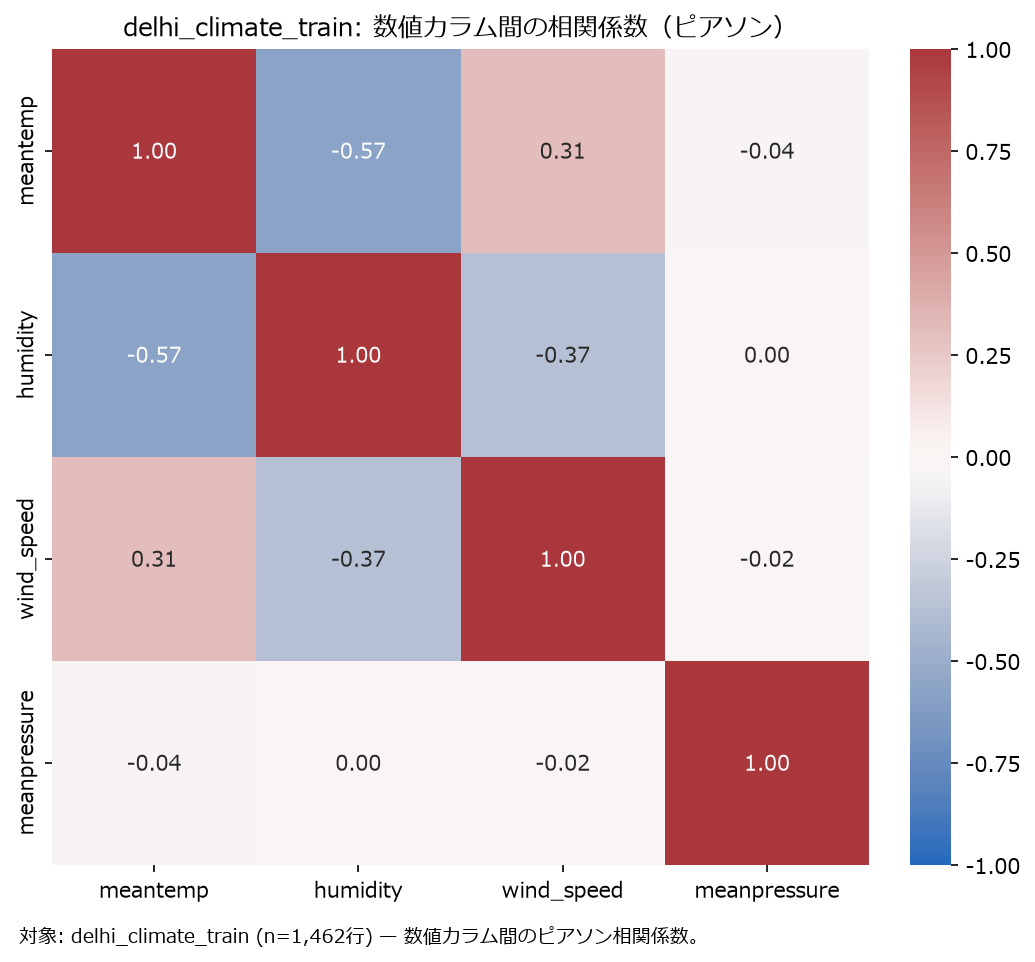

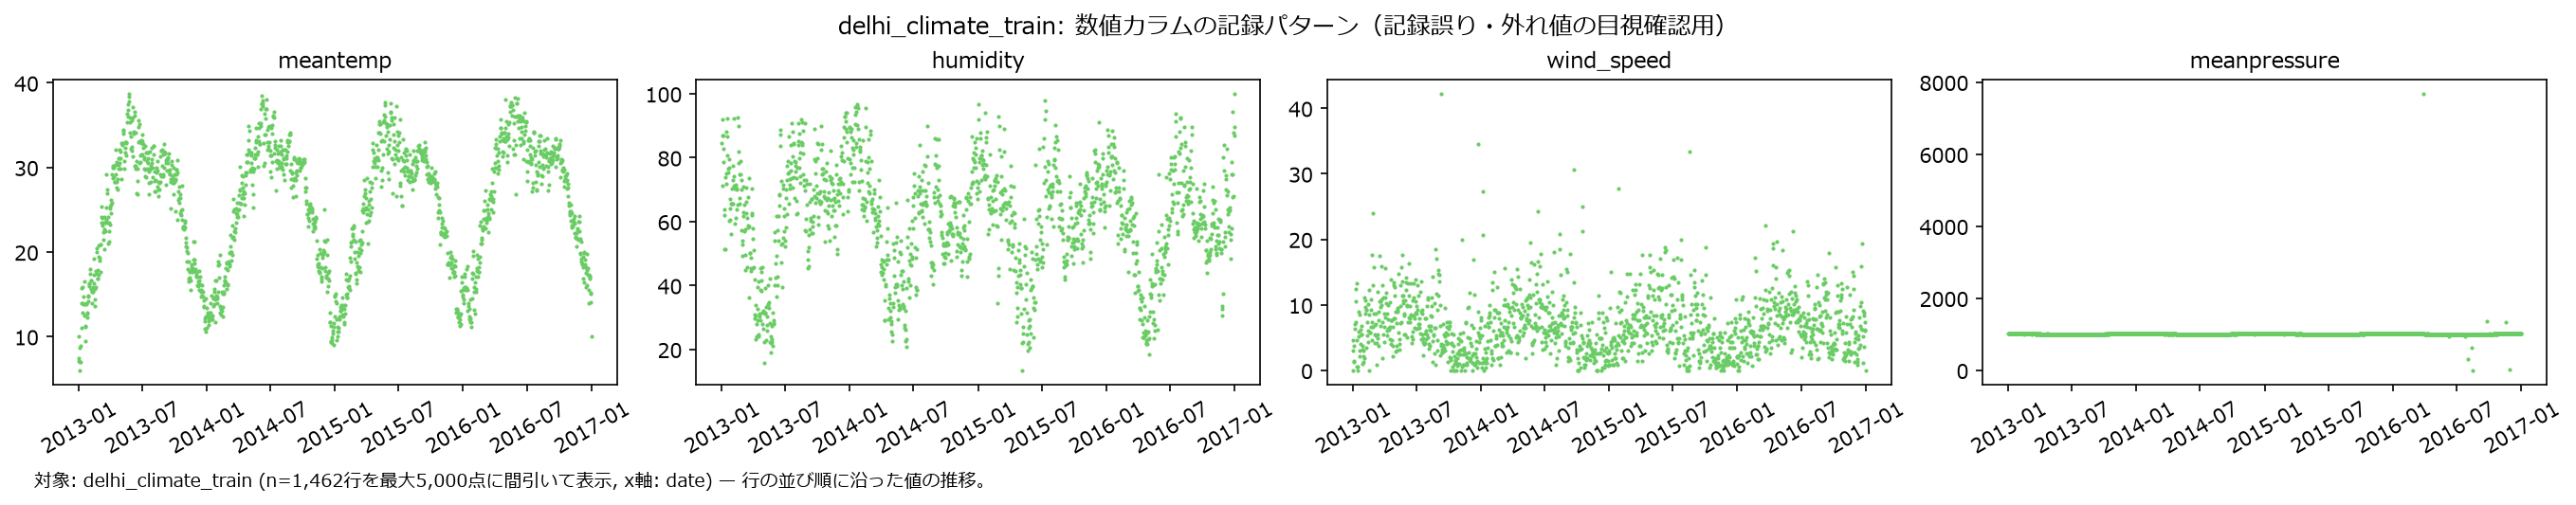

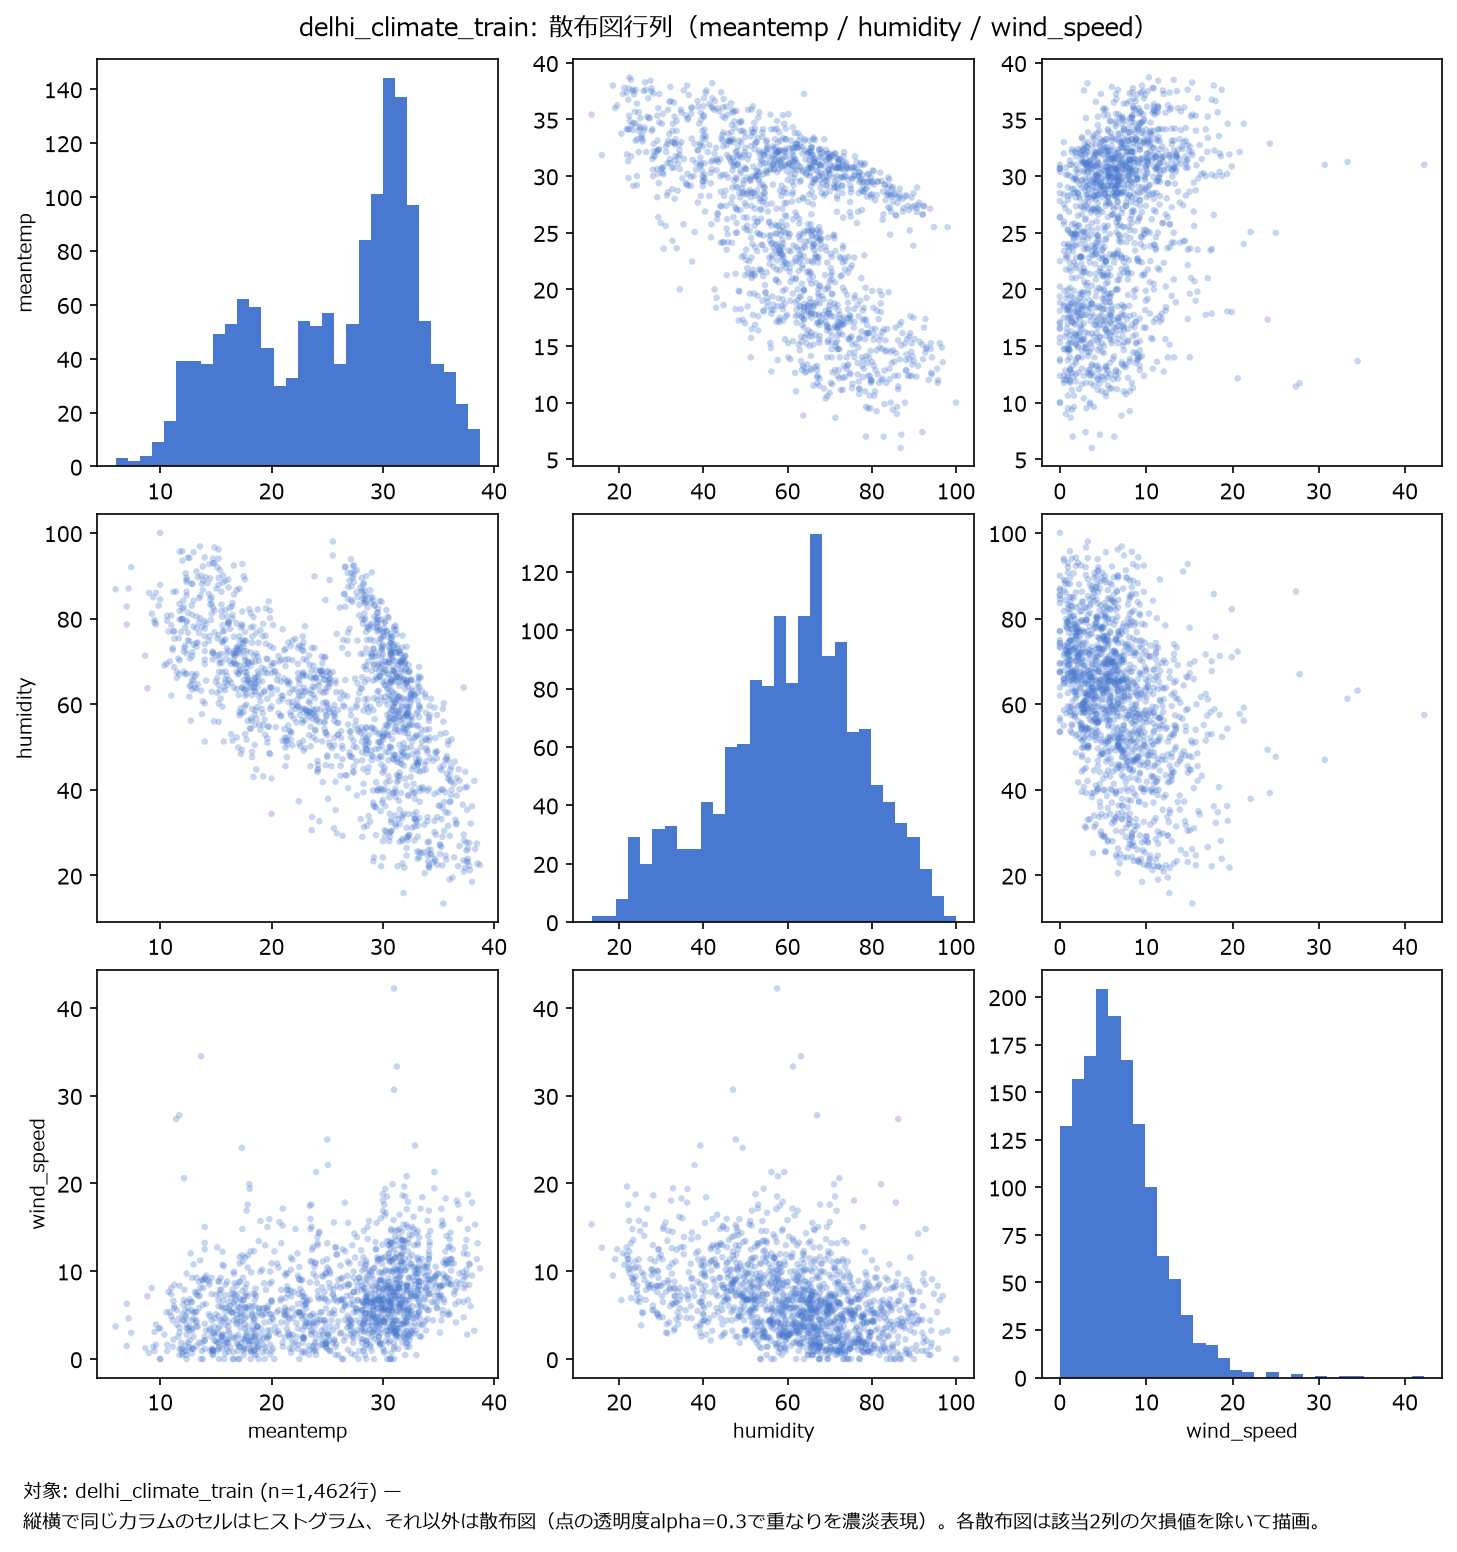

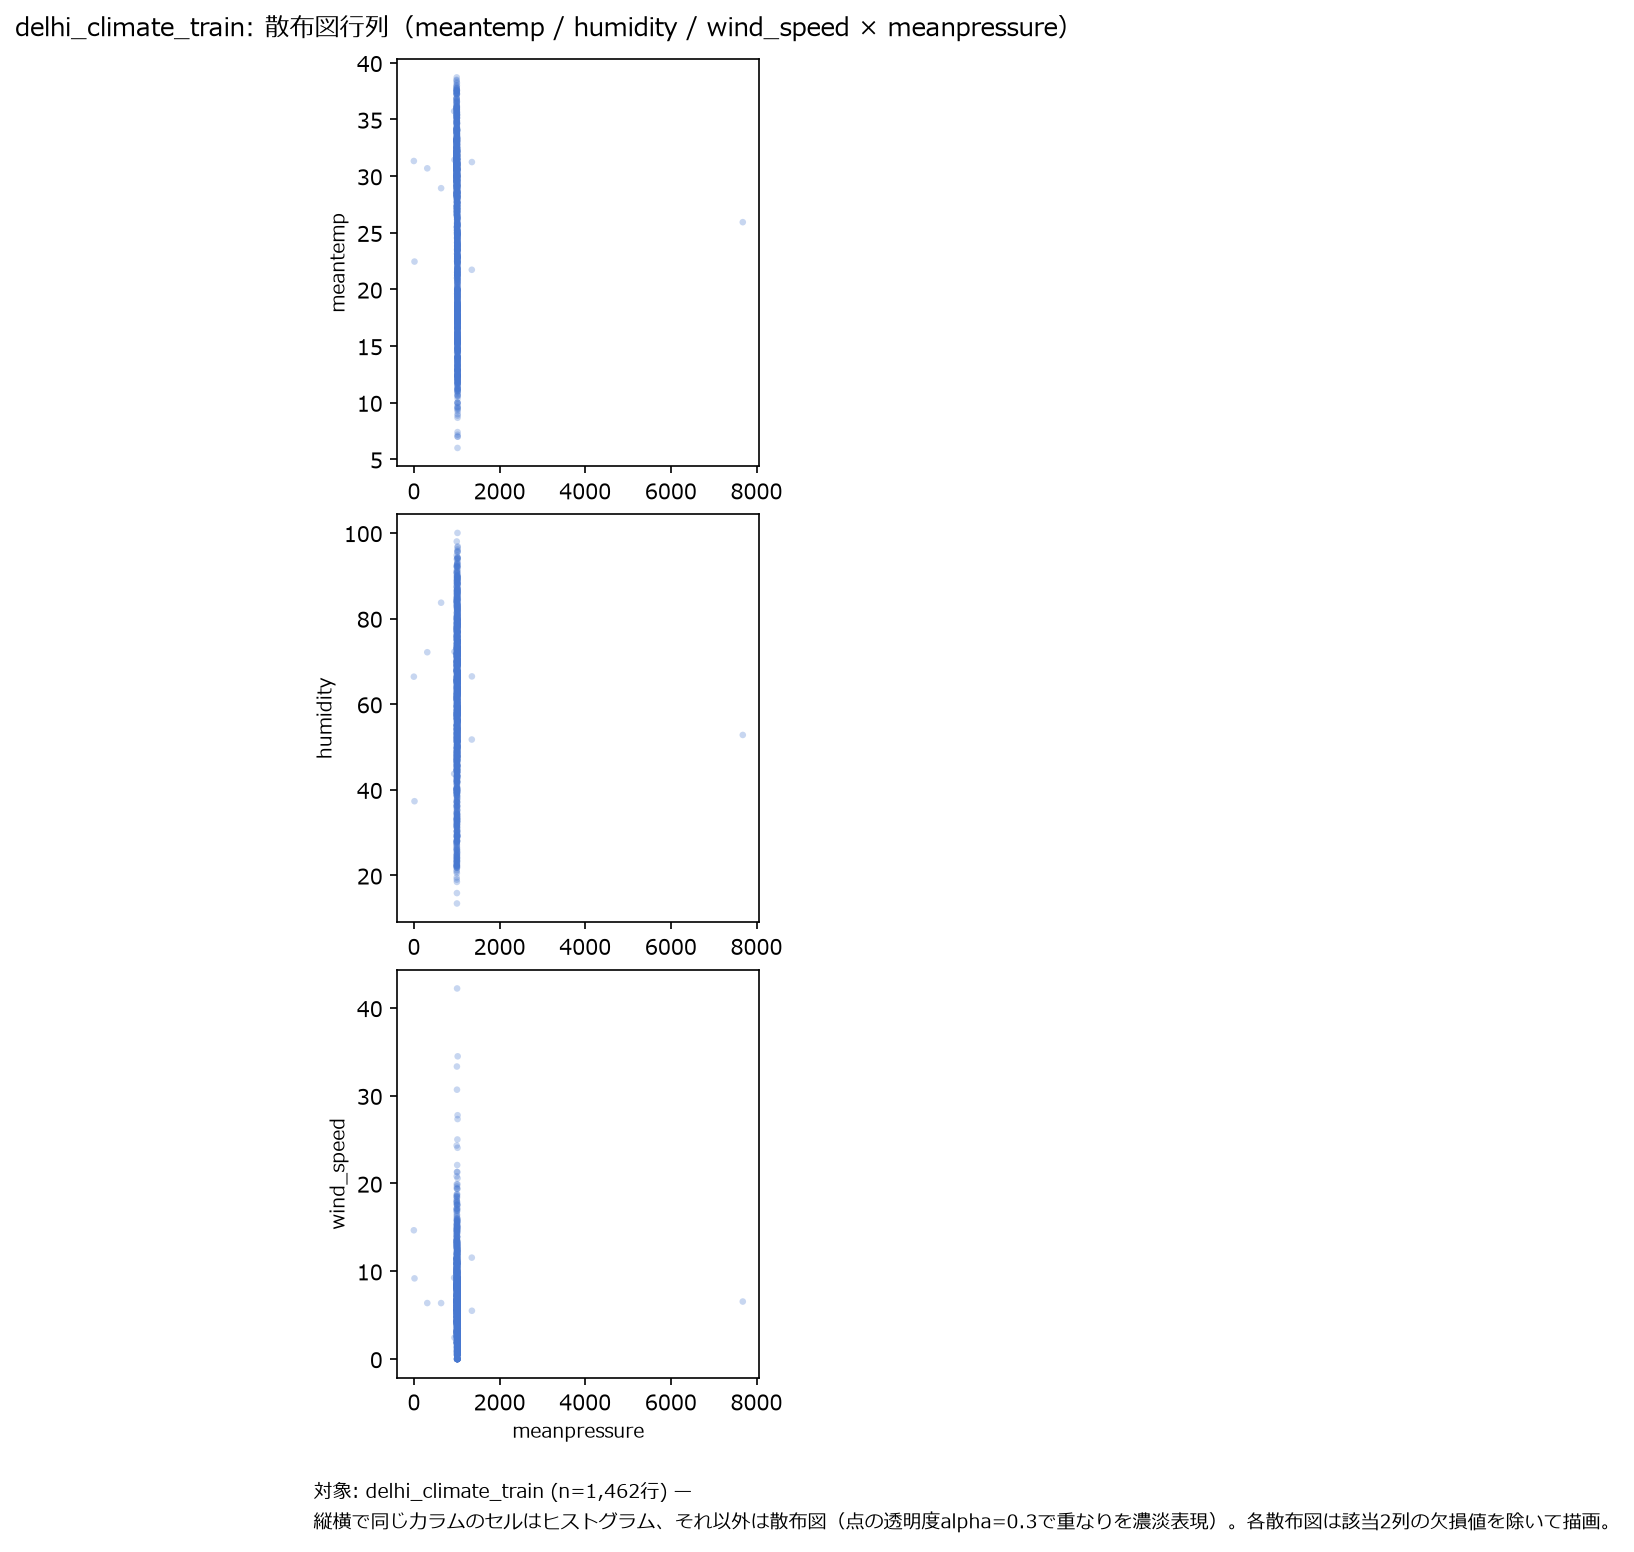

In [7]:
for kind in ("numeric_histograms", "correlation_heatmap", "record_pattern"):
    display(Image(filename=str(FIGURES_DIR / f"{DATASET_NAME}__{kind}.png"), width=900))

# 散布図行列は列数に応じて複数枚に分かれる
for path in sorted(FIGURES_DIR.glob(f"{DATASET_NAME}__scatter_matrix__*.png")):
    display(Image(filename=str(path), width=700))

## 5. 時系列診断

`run_time_series_checks` が、変数ごとに6種類の変換系列（原系列・対数・差分・対数差分・季節差分・季節対数差分）について、
「生値と移動平均」「ACF（自己相関）」「PACF（偏自己相関）」の図を作成します。

- **生値と移動平均**: 季節性・トレンド・異常値の有無を確認
- **ACF / PACF**: 何日前の値と相関があるか。ラグ特徴量の候補（何日前の値を特徴量にするか）を考える手がかり
- **季節差分（365日）**: 年周期の季節性を取り除いた後に残る変動

In [8]:
processed = run_time_series_checks(
    df,
    DATASET_NAME,
    FIGURES_DIR,
    moving_average_window=MOVING_AVERAGE_WINDOW,
    seasonal_period=SEASONAL_PERIOD,
    nlags=NLAGS,
)
print(f"時系列診断: {len(processed)}変数")
print("  " + ", ".join(processed))

時系列診断: 4変数
  delhi_climate_train:meantemp, delhi_climate_train:humidity, delhi_climate_train:wind_speed, delhi_climate_train:meanpressure


### 5.1 生値と移動平均（全変数）

=== meantemp ===


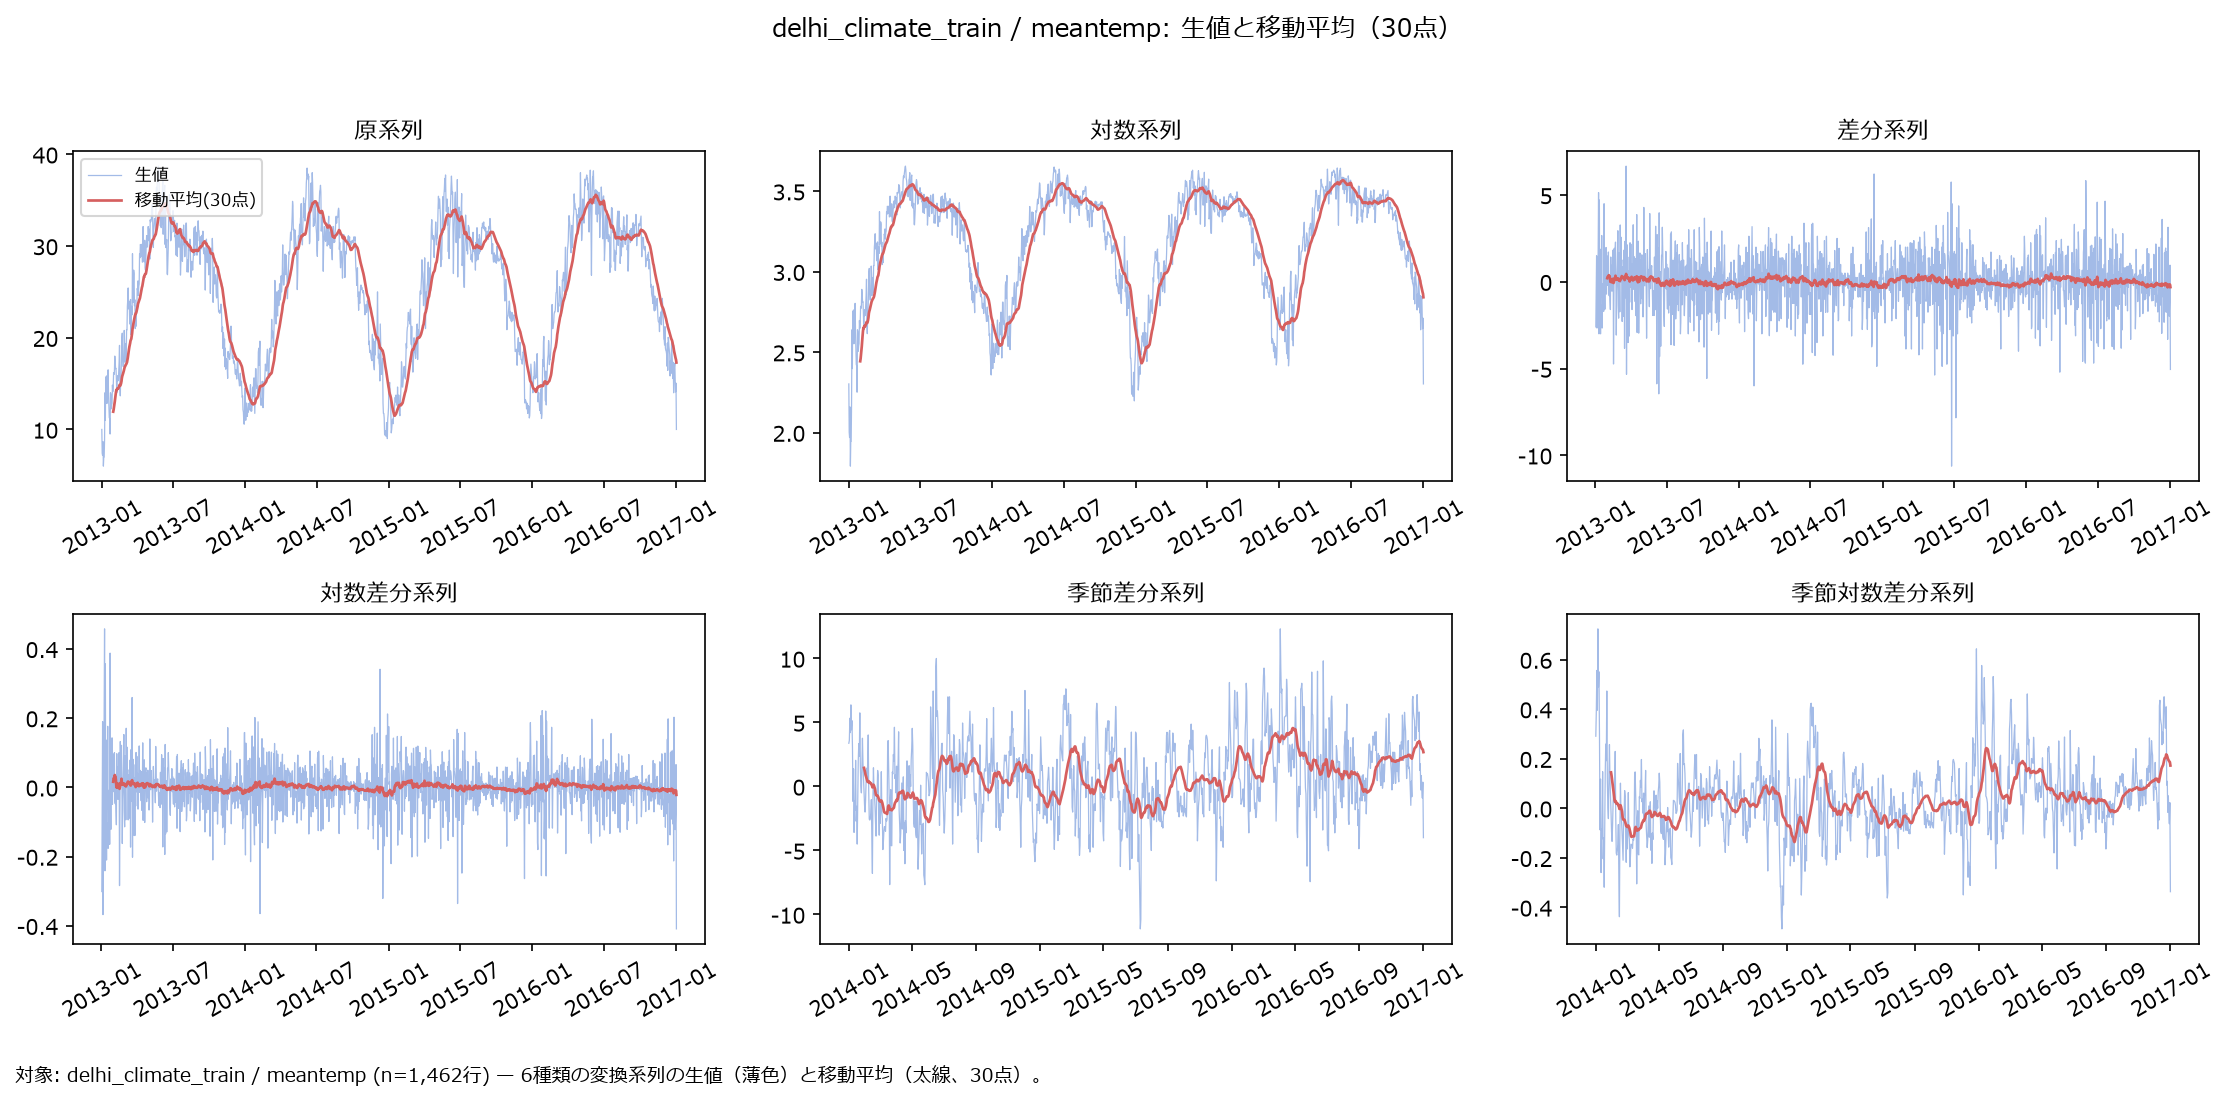

=== humidity ===


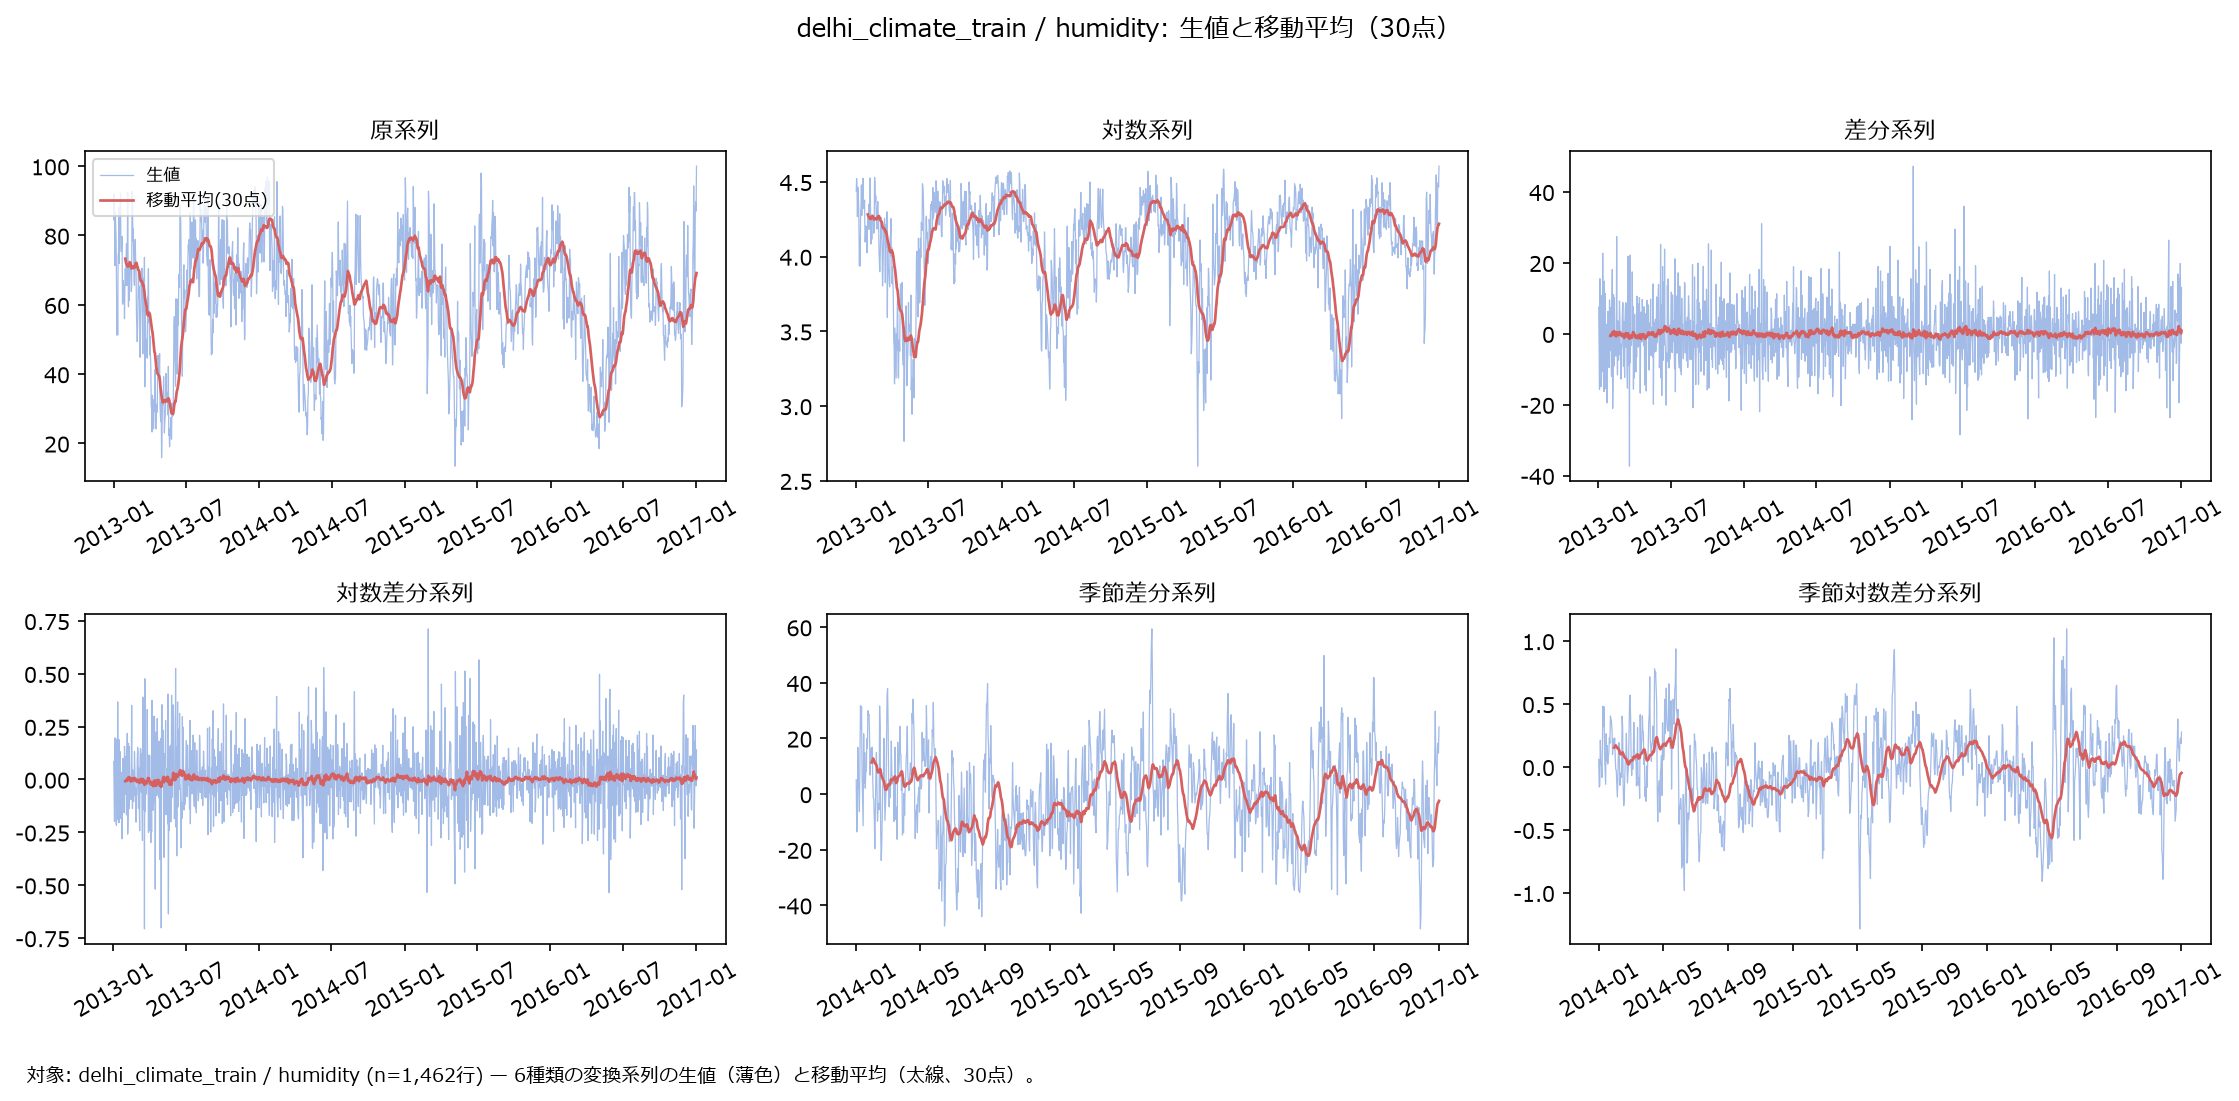

=== wind_speed ===


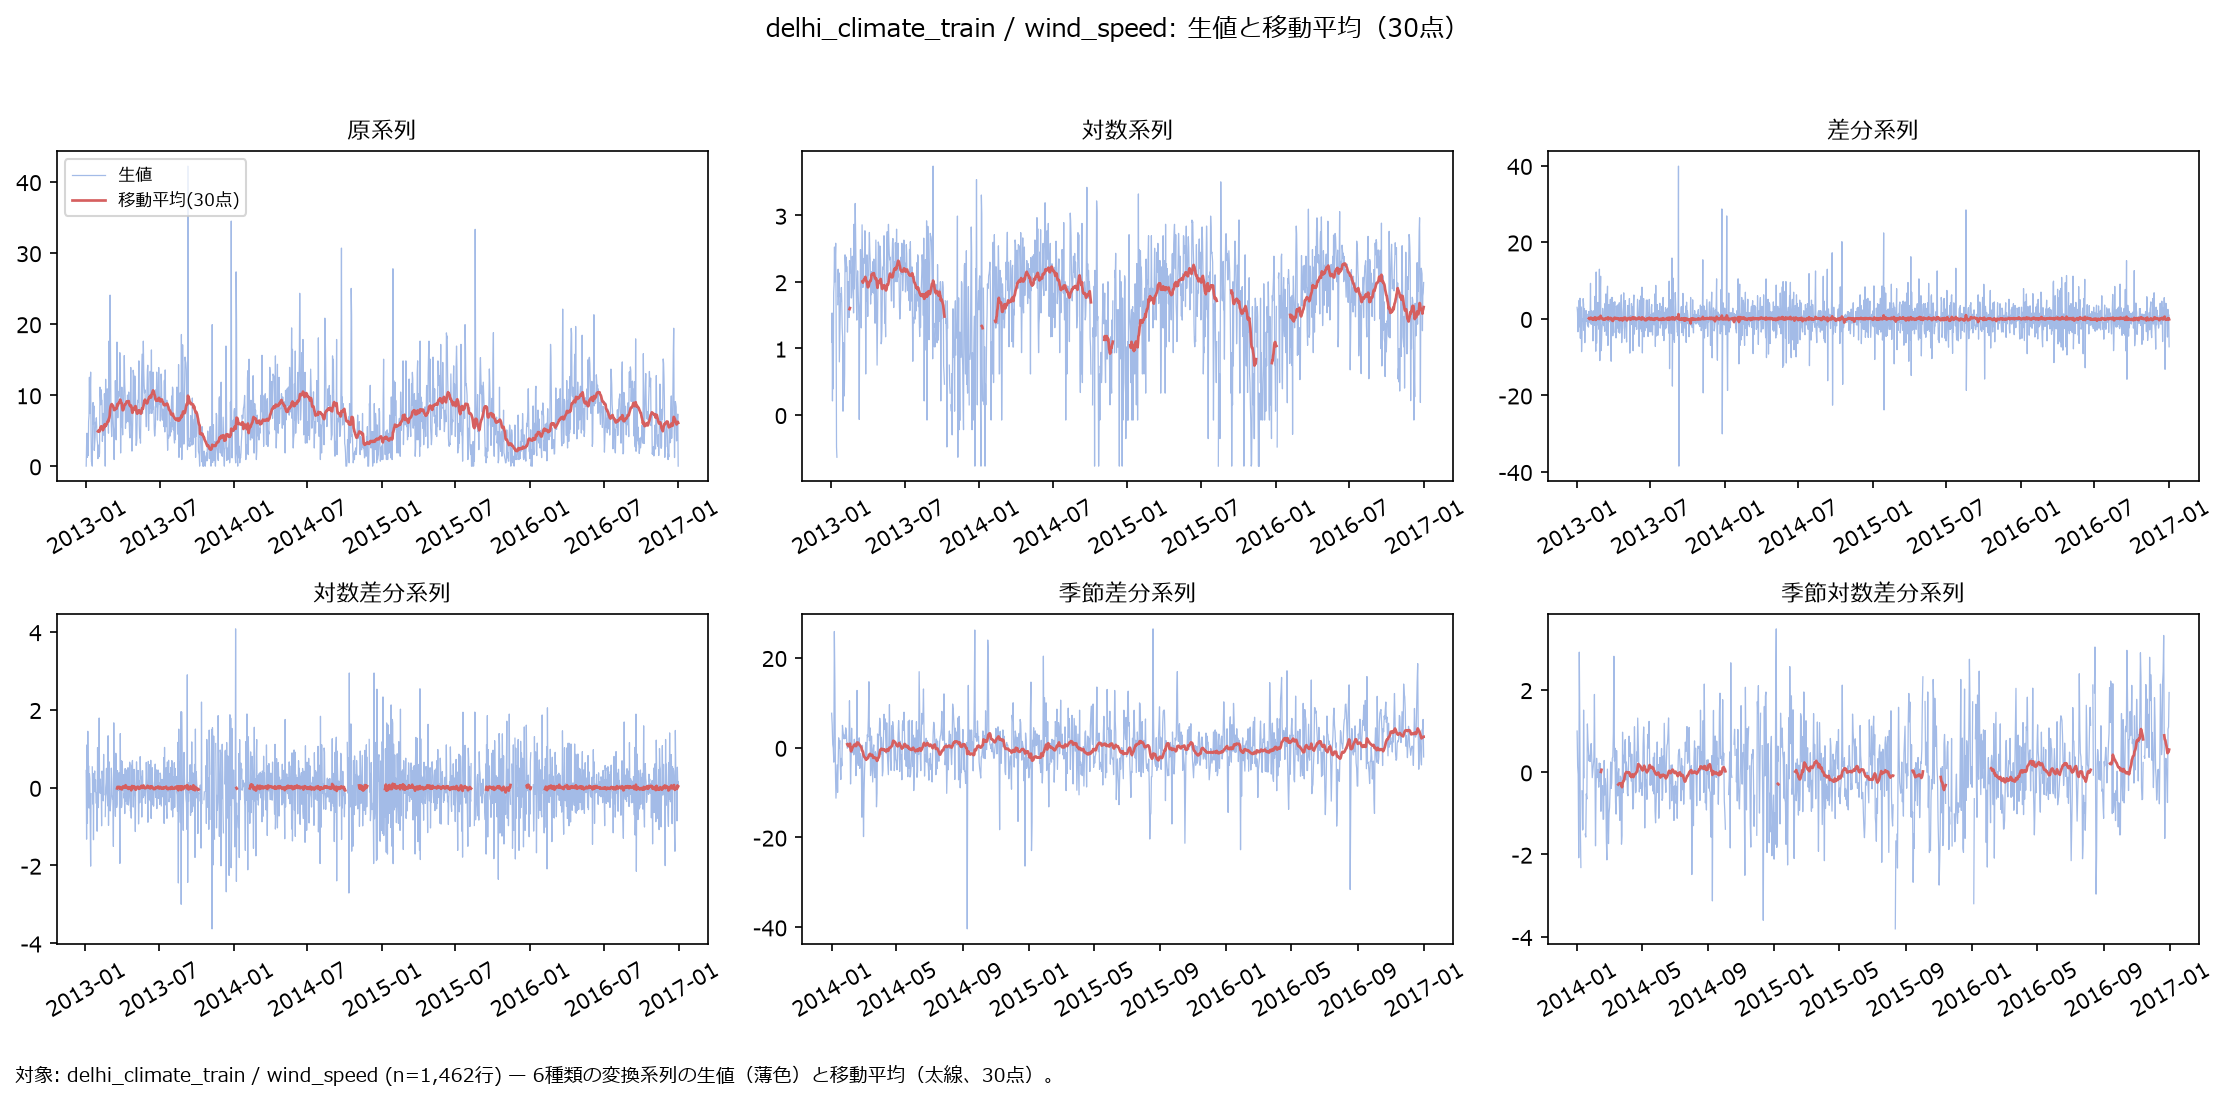

=== meanpressure ===


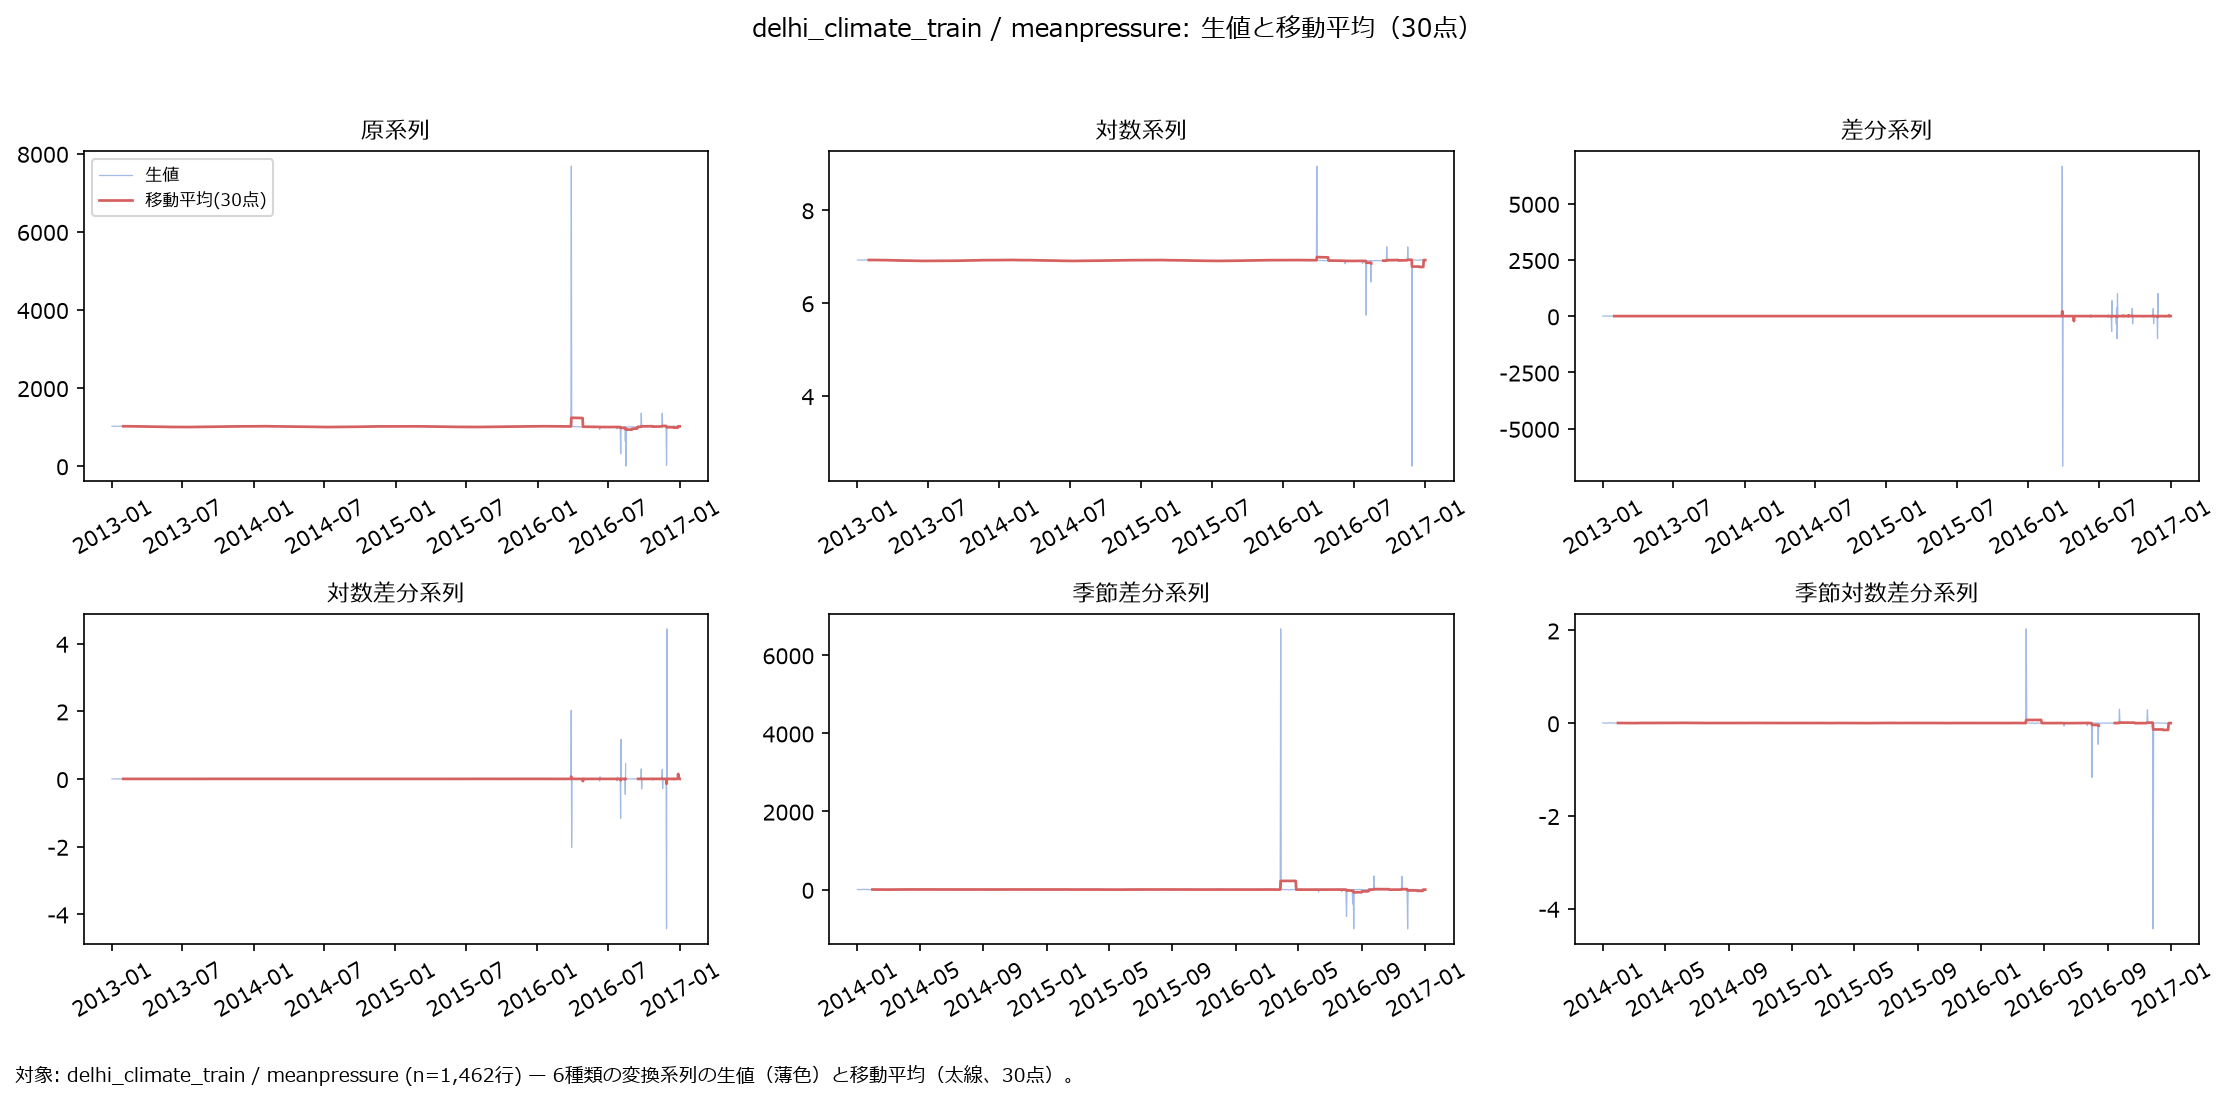

In [9]:
for variable in VARIABLE_LABELS:
    path = FIGURES_DIR / f"{DATASET_NAME}__{variable}__series_with_moving_average.png"
    print(f"=== {variable} ===")
    display(Image(filename=str(path), width=900))

### 5.2 ACF / PACF（日平均気温）

ここでは代表として `meantemp` の図を表示します。他の変数の図も同じ場所
（`{DATASET_NAME}__{変数名}__acf_correlogram.png` / `__pacf_correlogram.png`）に保存されています。

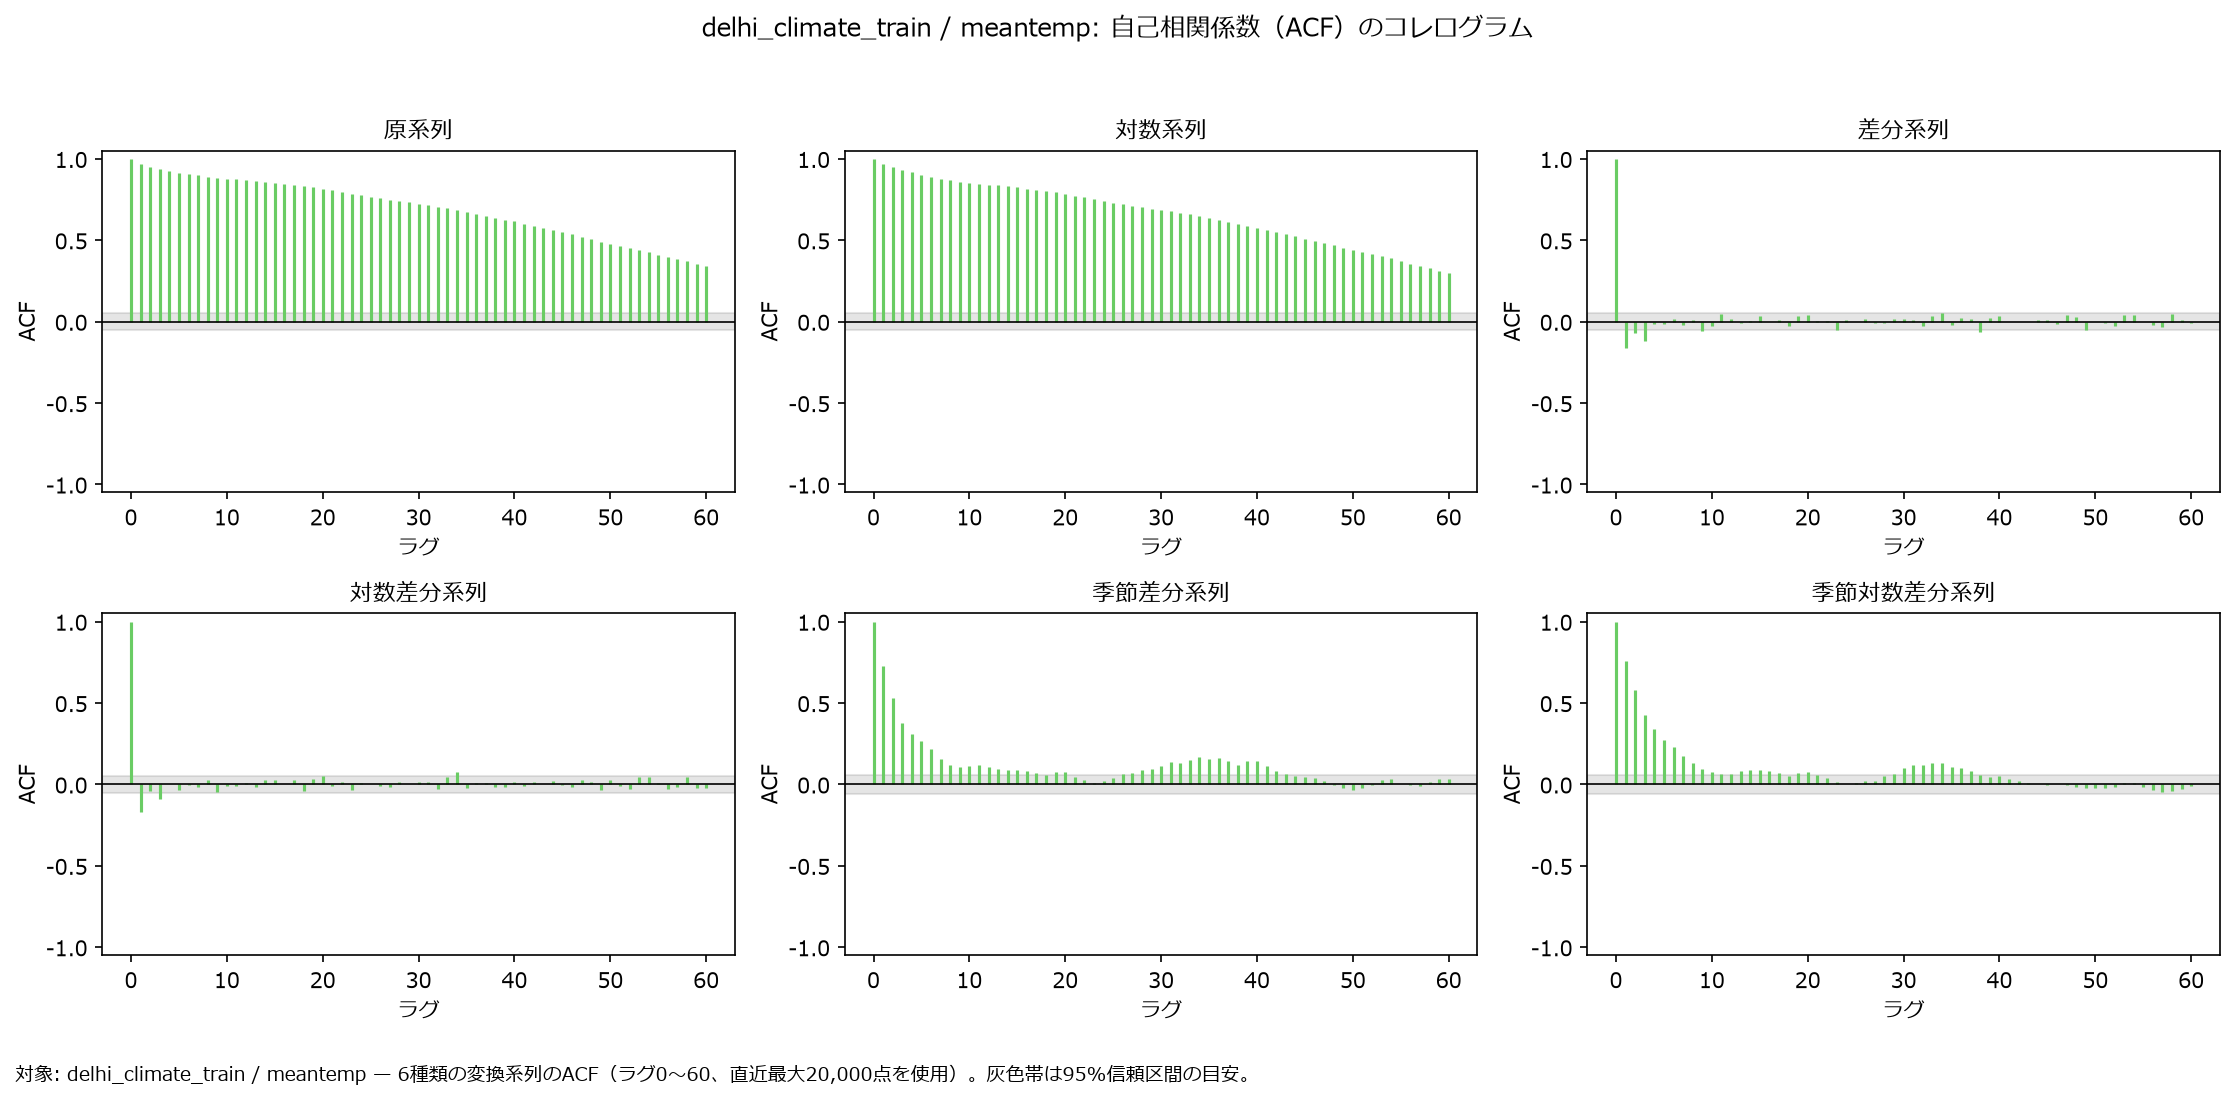

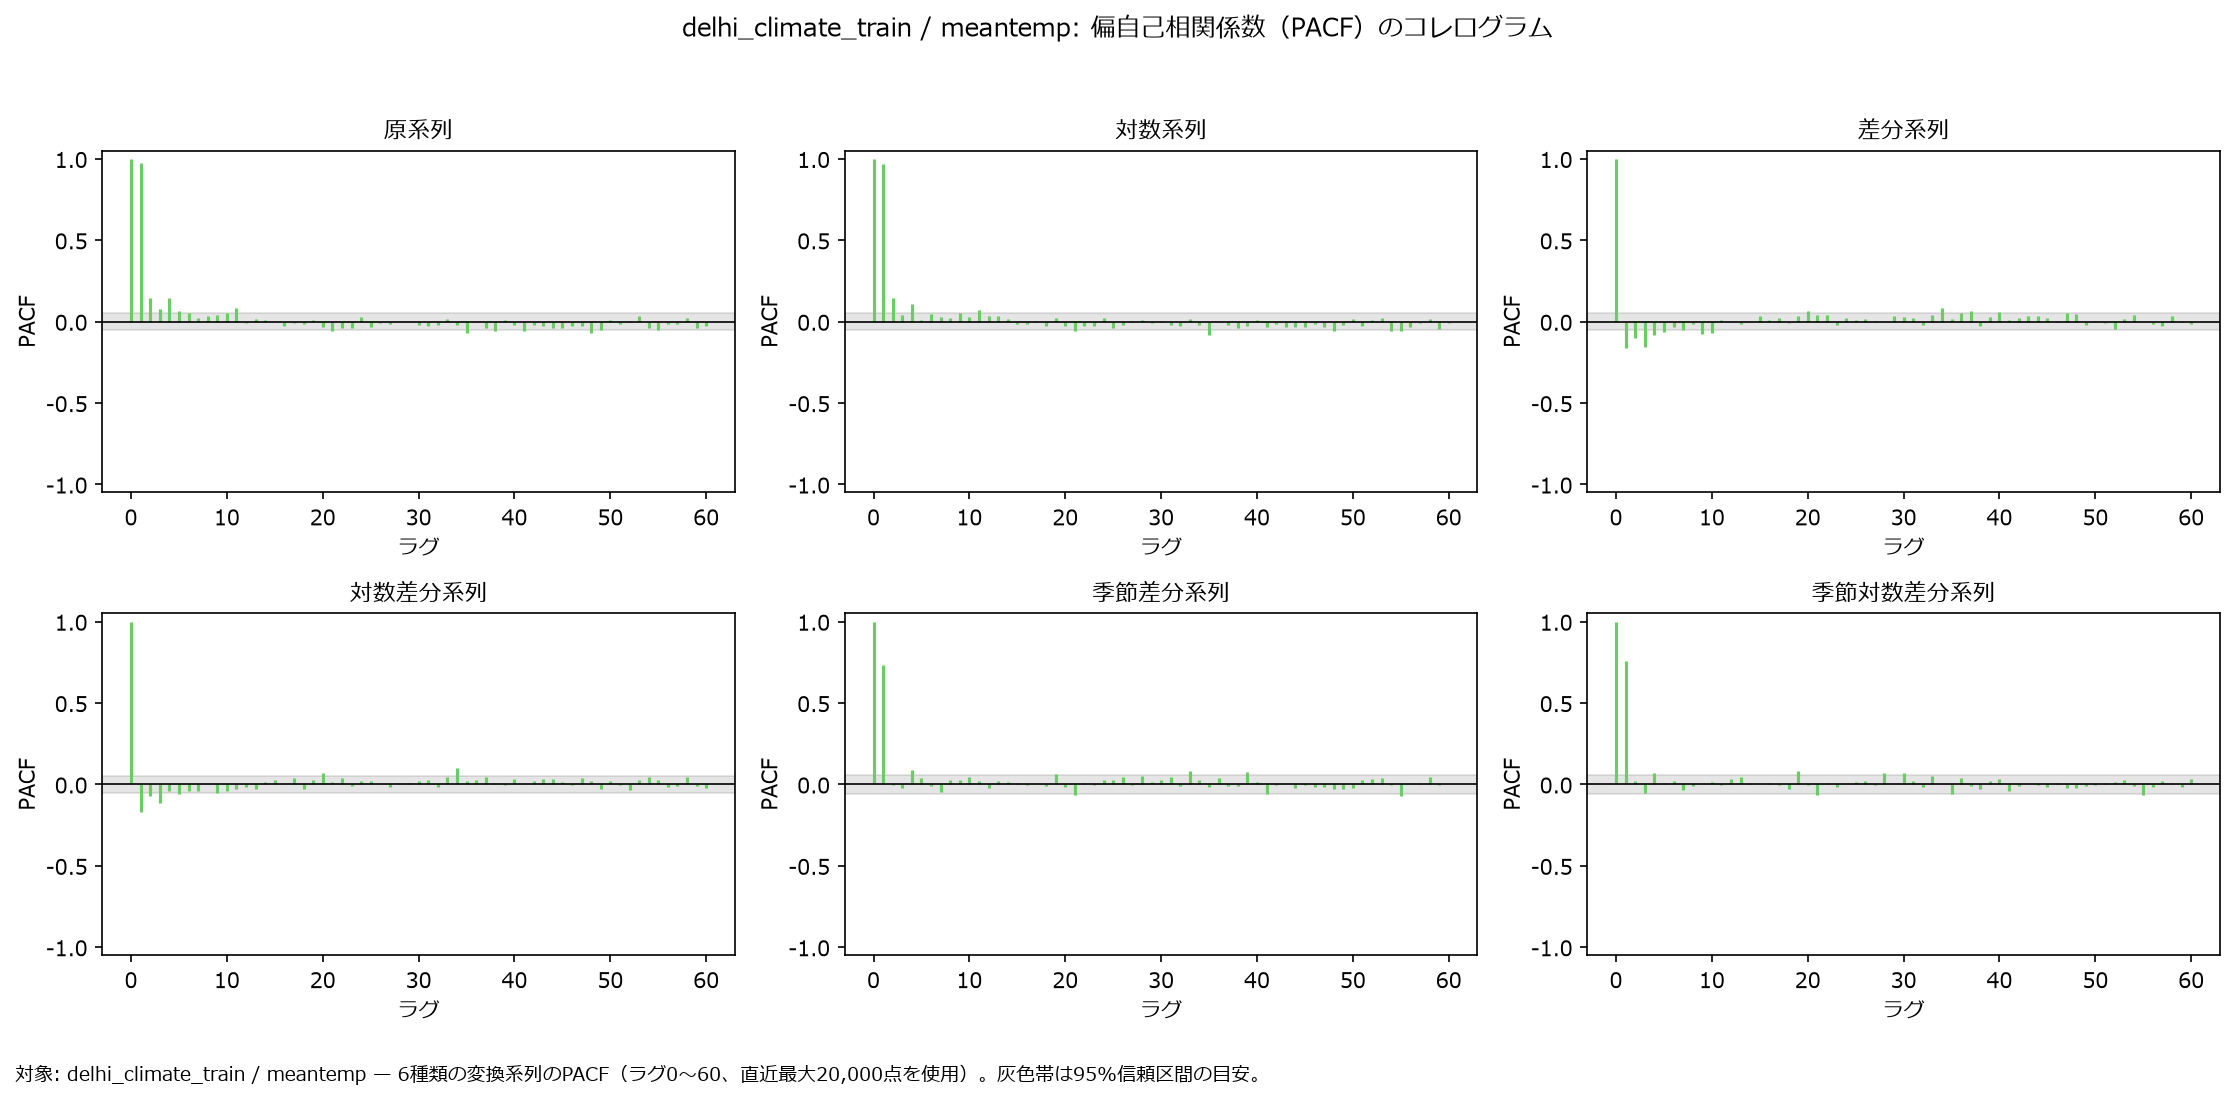

In [10]:
for kind in ("acf_correlogram", "pacf_correlogram"):
    display(Image(filename=str(FIGURES_DIR / f"{DATASET_NAME}__meantemp__{kind}.png"), width=900))

## 6. このデータ固有の確認

### 6.1 確認用の関数
- `date_continuity_summary`: 日付が1日刻みで欠けも重複もなく並んでいるか。時系列モデル（ラグ特徴量など）は
  「1行 = 1日」を前提にするため、欠けや重複があるとラグが意図した日数分ずれてしまう。
- `out_of_range_values`: 物理的にありうる範囲の外にある値の一覧。
- `yearly_means`: 年ごとの平均と日数。範囲外の値は1件でも平均を大きく歪めるため除外して平均する
  （例: 気圧 7679 hPa が1日あるだけで、その年の平均が約18 hPa上がる）。
- `plot_monthly_boxplots`: 月別の分布を箱ひげ図で描く。範囲外の値は縦軸を引き伸ばして分布が見えなくなるため描画から除外する。

In [11]:
def date_continuity_summary(df: pl.DataFrame, time_col: str = TIME_COL) -> pl.DataFrame:
    """日付が1日刻みで欠けも重複もなく並んでいるかを要約する。"""
    dates = df[time_col].cast(pl.Date)
    start, end = dates.min(), dates.max()
    # 開始日から終了日までの「あるべき日付」の一覧
    expected = pl.date_range(start, end, interval="1d", eager=True)
    missing = expected.filter(~expected.is_in(dates.implode()))
    return pl.DataFrame(
        {
            "start": [start],
            "end": [end],
            "n_rows": [df.height],
            "expected_days": [expected.len()],
            "missing_days": [missing.len()],
            "duplicated_days": [int(dates.is_duplicated().sum())],
        }
    )


def out_of_range_values(
    df: pl.DataFrame, ranges: dict[str, tuple[float, float]], time_col: str = TIME_COL
) -> pl.DataFrame:
    """物理的にありうる範囲の外にある値を、日付・変数・値の一覧で返す。"""
    frames = []
    for column, (lower, upper) in ranges.items():
        frames.append(
            df.filter(~pl.col(column).is_between(lower, upper)).select(
                pl.col(time_col),
                pl.lit(column).alias("variable"),
                pl.col(column).cast(pl.Float64).alias("value"),
                pl.lit(lower).alias("lower"),
                pl.lit(upper).alias("upper"),
            )
        )
    return pl.concat(frames).sort(time_col, "variable")


def yearly_means(
    df: pl.DataFrame, ranges: dict[str, tuple[float, float]], time_col: str = TIME_COL
) -> pl.DataFrame:
    """年ごとの平均と日数を集計する（範囲外の値は除外して平均する）。"""
    return (
        df.group_by(pl.col(time_col).dt.year().alias("year"))
        .agg(
            pl.len().alias("n_days"),
            *[
                # 範囲外の値を除いてから平均する
                pl.col(v).filter(pl.col(v).is_between(lower, upper)).mean()
                for v, (lower, upper) in ranges.items()
            ],
        )
        .sort("year")
    )


def plot_monthly_boxplots(
    df: pl.DataFrame,
    ranges: dict[str, tuple[float, float]],
    time_col: str = TIME_COL,
) -> plt.Figure:
    """変数ごとに、月別の分布を箱ひげ図で描く（季節性の確認）。"""
    sns.set_theme(style="whitegrid", palette="muted", font_scale=1.0)
    # sns.set_theme がフォント設定を上書きするため、その後に日本語フォントを設定する
    ensure_japanese_font()
    variables = list(ranges)
    fig, axes = plt.subplots(2, 2, figsize=(14, 9), constrained_layout=True)
    excluded_notes = []
    for ax, variable in zip(axes.flat, variables, strict=True):
        lower, upper = ranges[variable]
        in_range = df.filter(pl.col(variable).is_between(lower, upper))
        excluded = df.height - in_range.height
        if excluded:
            excluded_notes.append(f"{variable}: {excluded}件")
        plot_df = in_range.select(
            pl.col(time_col).dt.month().alias("month"), pl.col(variable)
        ).to_pandas()  # seabornに渡すためpandasに変換する
        sns.boxplot(data=plot_df, x="month", y=variable, ax=ax, color="#8fb3d9", fliersize=2)
        ax.set_title(f"{variable}: 月別の分布")
        ax.set_xlabel("月")
        ax.set_ylabel(VARIABLE_LABELS[variable])
    fig.suptitle(
        f"デリーの気候（学習データ）: 月別の分布 "
        f"（{df[time_col].min():%Y-%m-%d}〜{df[time_col].max():%Y-%m-%d}, n={df.height:,}日）"
    )
    note = "範囲外の値は描画から除外: " + ", ".join(excluded_notes) if excluded_notes else ""
    add_caption(fig, f"箱は四分位範囲、線は中央値、点は外れ値（1.5×IQRの外）。{note}")
    return fig

### 6.2 日付の連続性

欠けている日（`missing_days`）・重複している日（`duplicated_days`）が0なら、「1行 = 1日」とみなせます。

In [12]:
continuity = date_continuity_summary(df)
continuity.write_csv(ensure_parent_dir(TABLES_DIR / f"{DATASET_NAME}__date_continuity.csv"))
continuity

start,end,n_rows,expected_days,missing_days,duplicated_days
date,date,i64,i64,i64,i64
2013-01-01,2017-01-01,1462,1462,0,0


### 6.3 物理的にありうる範囲の外の値

記録の誤りの候補です。モデルの学習に使う場合は、欠損扱いにして補間するなどの前処理が必要です。

In [13]:
outliers = out_of_range_values(df, PLAUSIBLE_RANGES)
outliers.write_csv(TABLES_DIR / f"{DATASET_NAME}__out_of_range_values.csv")
print(f"範囲外の値: {outliers.height}件")
outliers

範囲外の値: 9件


date,variable,value,lower,upper
datetime[μs],str,f64,f64,f64
2016-03-28 00:00:00,"""meanpressure""",7679.333333,950.0,1050.0
2016-06-09 00:00:00,"""meanpressure""",938.066667,950.0,1050.0
2016-07-24 00:00:00,"""meanpressure""",946.3125,950.0,1050.0
2016-08-02 00:00:00,"""meanpressure""",310.4375,950.0,1050.0
2016-08-14 00:00:00,"""meanpressure""",633.9,950.0,1050.0
2016-08-16 00:00:00,"""meanpressure""",-3.041667,950.0,1050.0
2016-09-24 00:00:00,"""meanpressure""",1352.615385,950.0,1050.0
2016-11-17 00:00:00,"""meanpressure""",1350.296296,950.0,1050.0
2016-11-28 00:00:00,"""meanpressure""",12.045455,950.0,1050.0


### 6.4 年別の平均（範囲外の値を除く）

長期的な推移（温暖化・乾燥化など）や、年ごとの日数の欠けを確認します。
2017年は1日（2017-01-01）しかないため、他の年と平均を比べることはできません。

In [14]:
yearly = yearly_means(df, PLAUSIBLE_RANGES)
yearly.write_csv(TABLES_DIR / f"{DATASET_NAME}__yearly_means.csv")
yearly

year,n_days,meantemp,humidity,wind_speed,meanpressure
i32,u32,f64,f64,f64,f64
2013,365,24.791494,63.046292,6.827253,1007.642172
2014,365,25.010673,59.767942,6.756148,1008.347166
2015,365,25.114591,61.43049,6.480603,1008.834821
2016,366,27.103373,58.740174,7.16248,1008.229874
2017,1,10.0,100.0,0.0,1016.0


### 6.5 月別の分布（季節性）

図: C:\Users\imo_z\SIGNATE\analytics_cup_2026\outputs\figures\delhi_climate_train__monthly_boxplots.png


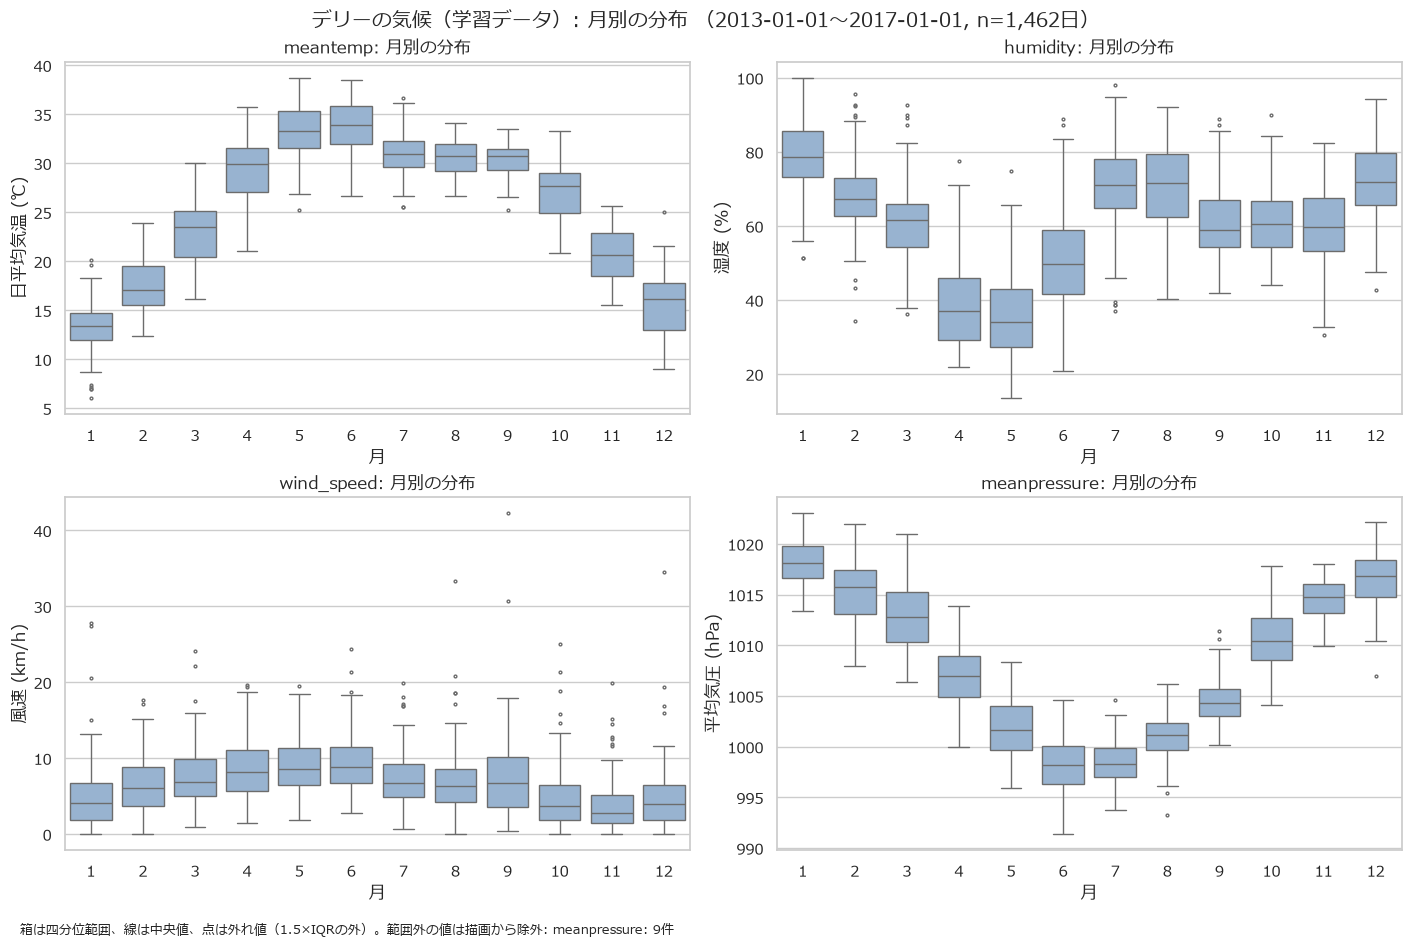

In [15]:
fig = plot_monthly_boxplots(df, PLAUSIBLE_RANGES)
figure_path = ensure_parent_dir(FIGURES_DIR / f"{DATASET_NAME}__monthly_boxplots.png")
fig.savefig(figure_path, dpi=150, bbox_inches="tight")
print(f"図: {figure_path}")
display(fig)
plt.close(fig)  # 二重表示を防ぎ、メモリを解放する

In [16]:
n_figures = len(list(FIGURES_DIR.glob(f"{DATASET_NAME}*.png")))
n_tables = len(list(TABLES_DIR.glob(f"{DATASET_NAME}*.csv")))
print(f"出力: 図 {n_figures}枚（{FIGURES_DIR}）, 表 {n_tables}件（{TABLES_DIR}）")

出力: 図 18枚（C:\Users\imo_z\SIGNATE\analytics_cup_2026\outputs\figures）, 表 5件（C:\Users\imo_z\SIGNATE\analytics_cup_2026\outputs\tables）


## 7. まとめと次のステップ

### 分かったこと（2013-01-01〜2017-01-01, 1,462日）
- **日付の連続性**: 欠けている日・重複している日は無く、「1行 = 1日」とみなせる。
- **記録の誤り**: `meanpressure` に物理的にありえない値が9件ある（7679, -3, 12, 310 hPa など）。
  いずれも2016年3月〜11月に集中している。他の3変数に範囲外の値は無い。
- **季節性**: 月別の分布に明確な年周期がある。
  - 気温: 5〜6月がピーク、1月が最低
  - 湿度: 4〜5月に低く、雨季（7〜8月）と冬に高い
  - 気圧: 夏に低く、冬に高い
  - 風速: 夏（4〜6月）にやや強い
- **長期的な推移**: 年平均気温は2013〜2015年の約25℃に対し、2016年は27.1℃と高い。

### モデル化に向けた注意点
- `meanpressure` の範囲外の値は、欠損扱いにして前後の日から補間するなどの前処理が必要
  （そのままラグ特徴量に使うと、予測が大きく乱れる）。
- 年周期の季節性が強いため、月・日などのカレンダー特徴量や、長めの移動平均が有効と考えられる。
- 2016年の気温が高いことは、学習期間の直後（2017年）の予測で水準がずれる要因になりうる。

### 次のステップの例
- `notebook/001_quickstart_delhi_climate.ipynb` で、この知見を踏まえた予測モデルを作る。
- 範囲の閾値（本ノートブックの仮定）を、気象の公開データなどと照らして妥当か確認する。